<a href="https://colab.research.google.com/github/zhangminxi-bit/Breakout-Success-Predictor/blob/main/3916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [ ]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

import yfinance as yf
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can pre-breakout price and volume characteristics predict whether a stock's
breakout will succeed (positive 5-day return) or fail (price closes back
below the breakout level within 5 days) at the moment the signal fires?

**This is a prediction (umbrella) problem because:** We are not claiming that
any feature causes a breakout to succeed. We are asking whether patterns
observable at the moment of breakout are associated with future outcomes in a way that enables classification. No causal inference is made.

**The decision this enables:** This analysis would help a retail trader or quantitative analyst decide whether to enter a position when a breakout signal fires, or wait for additional confirmation before committing capital.

**Dataset:** past 5 years of closing price of AAPL, MSFT, NVDA, XLF, and XLV  
- **Source:** Yahoo Finance via `yfinance` (https://finance.yahoo.com)
- **N =** 6280
- **Features =** breakout_strength, volume_ratio, ret_prior_5d, ret_prior_20d,
  volatility_20d, atr_ratio, ticker
- **Target variable =** success = 1  if ret_5d > 0  AND  failed_5d == 0, success = 0  otherwise
- **Access date:** April 16, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [ ]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# ── Constants ────────────────────────────────────────────────
TICKERS  = ['AAPL', 'MSFT', 'NVDA', 'XLF', 'XLV',
            'AMZN', 'GOOGL', 'META', 'JPM', 'UNH']
LOOKBACK = 20   # rolling window for prior high
COOLDOWN = 5    # days to suppress after a breakout fires
HORIZONS = [3, 5, 10, 20]

# ── Download 5 years of daily OHLCV data ─────────────────────
print('Downloading 5 years of daily data from Yahoo Finance...')
raw = yf.download(TICKERS, period='5y', interval='1d', auto_adjust=True)

close_wide  = raw['Close']
volume_wide = raw['Volume']
high_wide   = raw['High']
low_wide    = raw['Low']

# Reshape to long format
frames = []
for t in TICKERS:
    tmp = pd.DataFrame({
        'Date':   close_wide.index,
        'Ticker': t,
        'Close':  close_wide[t].values,
        'High':   high_wide[t].values,
        'Low':    low_wide[t].values,
        'Volume': volume_wide[t].values
    })
    frames.append(tmp)

df = pd.concat(frames).dropna().sort_values(['Ticker','Date']).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])

[*********************100%***********************]  10 of 10 completed


In [ ]:
# ── Breakout signal with cooldown filter ─────────────────────
def compute_signals(group):
    group = group.copy().sort_values('Date').reset_index(drop=True)
    closes = group['Close'].values
    highs  = group['High'].values
    lows   = group['Low'].values
    vols   = group['Volume'].values
    n      = len(group)

    # 20-day rolling high of PRIOR closes (shift by 1 — no look-ahead)
    group['high_20d'] = (group['Close'].shift(1)
                         .rolling(LOOKBACK, min_periods=LOOKBACK).max())

    # Breakout flag with cooldown
    group['raw_breakout'] = (group['Close'] > group['high_20d']).astype(int)
    group['breakout'] = 0
    last_b = -COOLDOWN - 1
    for i in range(n):
        if group.loc[i, 'raw_breakout'] == 1 and (i - last_b) > COOLDOWN:
            group.loc[i, 'breakout'] = 1
            last_b = i

    # Forward returns
    for h in HORIZONS:
        fwd = np.full(n, np.nan)
        for i in range(n):
            if i + h < n:
                fwd[i] = (closes[i+h] - closes[i]) / closes[i]
        group[f'ret_{h}d'] = fwd

    # Failure flag — any close below breakout level within 5 days
    failed = np.full(n, np.nan)
    for i in range(n):
        if group.loc[i, 'breakout'] == 1:
            window = closes[i+1 : i+6]
            if len(window) == 5:
                failed[i] = int(any(window < closes[i]))
    group['failed_5d'] = failed

    # ATR (Average True Range)
    tr = np.maximum(
        highs - lows,
        np.maximum(
            np.abs(highs - np.roll(closes, 1)),
            np.abs(lows  - np.roll(closes, 1))
        )
    )
    tr[0] = highs[0] - lows[0]
    group['atr'] = pd.Series(tr).rolling(14).mean().values

    return group

df = (df.groupby('Ticker', group_keys=False)
        .apply(compute_signals)
        .reset_index(drop=True))

counts = df[df['breakout'] == 1].groupby('Ticker').size()
print('Breakout counts per ticker:')
print(counts.to_string())
print(f'\nTotal raw breakout events: {counts.sum()}')

Breakout counts per ticker:
Ticker
AAPL     70
AMZN     64
GOOGL    76
JPM      68
META     65
MSFT     69
NVDA     78
UNH      63
XLF      75
XLV      61

Total raw breakout events: 689


In [ ]:
# ── Engineer features at breakout day (t=0 only) ─────────────
def engineer_features(group):
    group = group.copy().sort_values('Date').reset_index(drop=True)
    closes = group['Close'].values
    vols   = group['Volume'].values
    n      = len(group)

    # How far above the 20-day high did price close?
    group['breakout_strength'] = (
        (group['Close'] - group['high_20d']) / group['high_20d']
    )

    # Volume today vs 20-day average volume
    group['vol_avg_20d']  = (group['Volume'].shift(1)
                              .rolling(20, min_periods=10).mean())
    group['volume_ratio'] = group['Volume'] / group['vol_avg_20d']

    # Prior 5-day and 20-day returns leading into the breakout
    ret_5  = np.full(n, np.nan)
    ret_20 = np.full(n, np.nan)
    for i in range(n):
        if i >= 5:
            ret_5[i]  = (closes[i] - closes[i-5])  / closes[i-5]
        if i >= 20:
            ret_20[i] = (closes[i] - closes[i-20]) / closes[i-20]
    group['ret_prior_5d']  = ret_5
    group['ret_prior_20d'] = ret_20

    # 20-day rolling volatility of daily returns
    group['daily_ret']    = group['Close'].pct_change()
    group['volatility_20d'] = (group['daily_ret']
                                .rolling(20, min_periods=10).std())

    # ATR ratio — normalized intraday noise
    group['atr_ratio'] = group['atr'] / group['Close']

    return group

df = (df.groupby('Ticker', group_keys=False)
        .apply(engineer_features)
        .reset_index(drop=True))

# ── Build final event table ───────────────────────────────────
FEATURE_COLS = ['breakout_strength', 'volume_ratio', 'ret_prior_5d',
                'ret_prior_20d', 'volatility_20d', 'atr_ratio']

event_table = (
    df[df['breakout'] == 1]
    [['Date','Ticker','Close','high_20d','Volume','ret_5d','failed_5d']
     + FEATURE_COLS]
    .dropna()
    .copy()
    .reset_index(drop=True)
)

# Target variable: success = 1 if ret_5d > 0 AND did not fail within 5 days
event_table['success'] = (
    event_table['ret_5d'] > 0
).astype(int)

# One-hot encode ticker
ticker_dummies = pd.get_dummies(event_table['Ticker'], prefix='ticker',
                                 drop_first=True)
event_table = pd.concat([event_table, ticker_dummies], axis=1)

### 2.2 Basic Description

In [ ]:
# ============================================================
# 2.2 Describe your data
# ============================================================

print(f'Final event table: {len(event_table)} observations')
print(f'\nFeature columns: {FEATURE_COLS}')
print(f'\nTarget distribution:')
print(event_table['success'].value_counts())
print(f'\nSuccess rate: {event_table["success"].mean():.1%}')
event_table[FEATURE_COLS + ['success']].describe().round(4)

Final event table: 683 observations

Feature columns: ['breakout_strength', 'volume_ratio', 'ret_prior_5d', 'ret_prior_20d', 'volatility_20d', 'atr_ratio']

Target distribution:
success
1    390
0    293
Name: count, dtype: int64

Success rate: 57.1%


,breakout_strength,volume_ratio,ret_prior_5d,ret_prior_20d,volatility_20d,atr_ratio,success
count,683.0000,683.0000,683.0000,683.0000,683.0000,683.0000,683.0000
mean,0.0116,1.1453,0.0379,0.0789,0.0165,0.0217,0.5710
std,0.0151,0.5546,0.0315,0.0704,0.0087,0.0091,0.4953
min,0.0000,0.4395,0.0001,0.0001,0.0045,0.0078,0.0000
25%,0.0031,0.8329,0.0165,0.0327,0.0103,0.0150,0.0000
50%,0.0070,1.0057,0.0293,0.0595,0.0147,0.0201,1.0000
75%,0.0143,1.2476,0.0505,0.1005,0.0205,0.0266,1.0000
max,0.1989,5.8154,0.2117,0.4885,0.0596,0.0677,1.0000


In [ ]:
event_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               683 non-null    datetime64[ns]
 1   Ticker             683 non-null    object        
 2   Close              683 non-null    float64       
 3   high_20d           683 non-null    float64       
 4   Volume             683 non-null    int64         
 5   ret_5d             683 non-null    float64       
 6   failed_5d          683 non-null    float64       
 7   breakout_strength  683 non-null    float64       
 8   volume_ratio       683 non-null    float64       
 9   ret_prior_5d       683 non-null    float64       
 10  ret_prior_20d      683 non-null    float64       
 11  volatility_20d     683 non-null    float64       
 12  atr_ratio          683 non-null    float64       
 13  success            683 non-null    int64         
 14  ticker_AMZ

### 2.3 Missing Data Assessment

Missing data (%) by column:
failed_5d            0.9456
ret_20d              0.0159
high_20d             0.0159
breakout_strength    0.0159
ret_prior_20d        0.0159
atr_ratio            0.0104
atr                  0.0104
volatility_20d       0.0080
volume_ratio         0.0080
vol_avg_20d          0.0080
ret_10d              0.0080
ret_prior_5d         0.0040
ret_5d               0.0040
ret_3d               0.0024
daily_ret            0.0008
dtype: float64


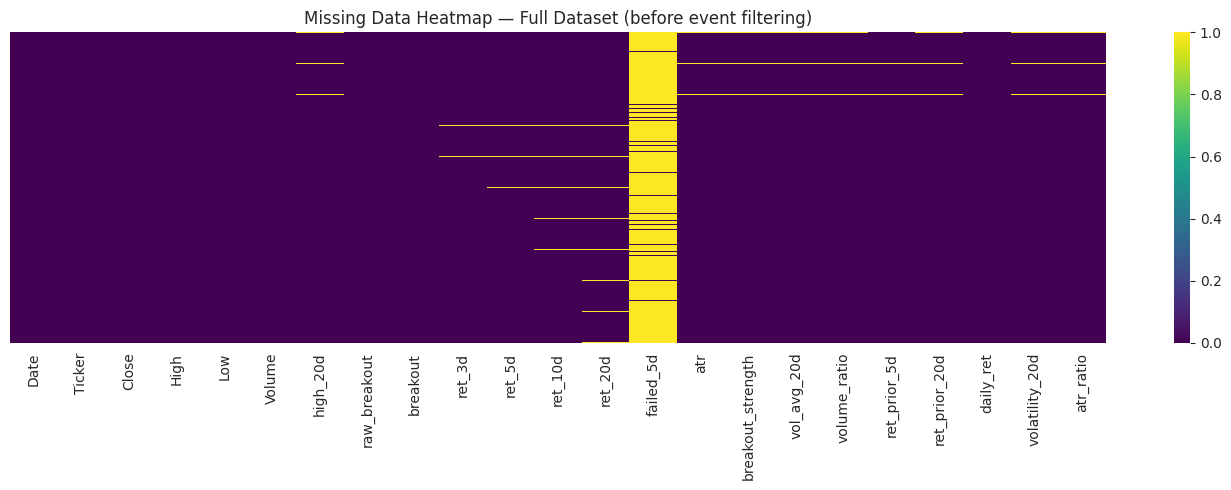


Missing values in event table (after .dropna()):
breakout_strength    0
volume_ratio         0
ret_prior_5d         0
ret_prior_20d        0
volatility_20d       0
atr_ratio            0
success              0
dtype: int64


In [ ]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0].round(4))

# Visual: missing data heatmap on full df
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap — Full Dataset (before event filtering)')
plt.tight_layout()
plt.show()

# Confirm zero missing in event table after .dropna()
print('\nMissing values in event table (after .dropna()):')
print(event_table[FEATURE_COLS + ['success']].isnull().sum())

**Missing data strategy:** The missingness pattern is **MCAR (Missing Completely At Random)**

Missing values arise for two structural reasons: (1) rolling windows at the *start* of each ticker's series require 20 prior days before they can compute:  these rows have no data yet, not because of anything related to the outcome; (2) forward return columns near the *end* of the series have no future data available yet. Both causes are purely mechanical and completely independent of whether a breakout succeeds or fails. Strategy: drop via `.dropna()` when building the event table. All missing values are eliminated before modeling.

### 2.4 Distribution Plots

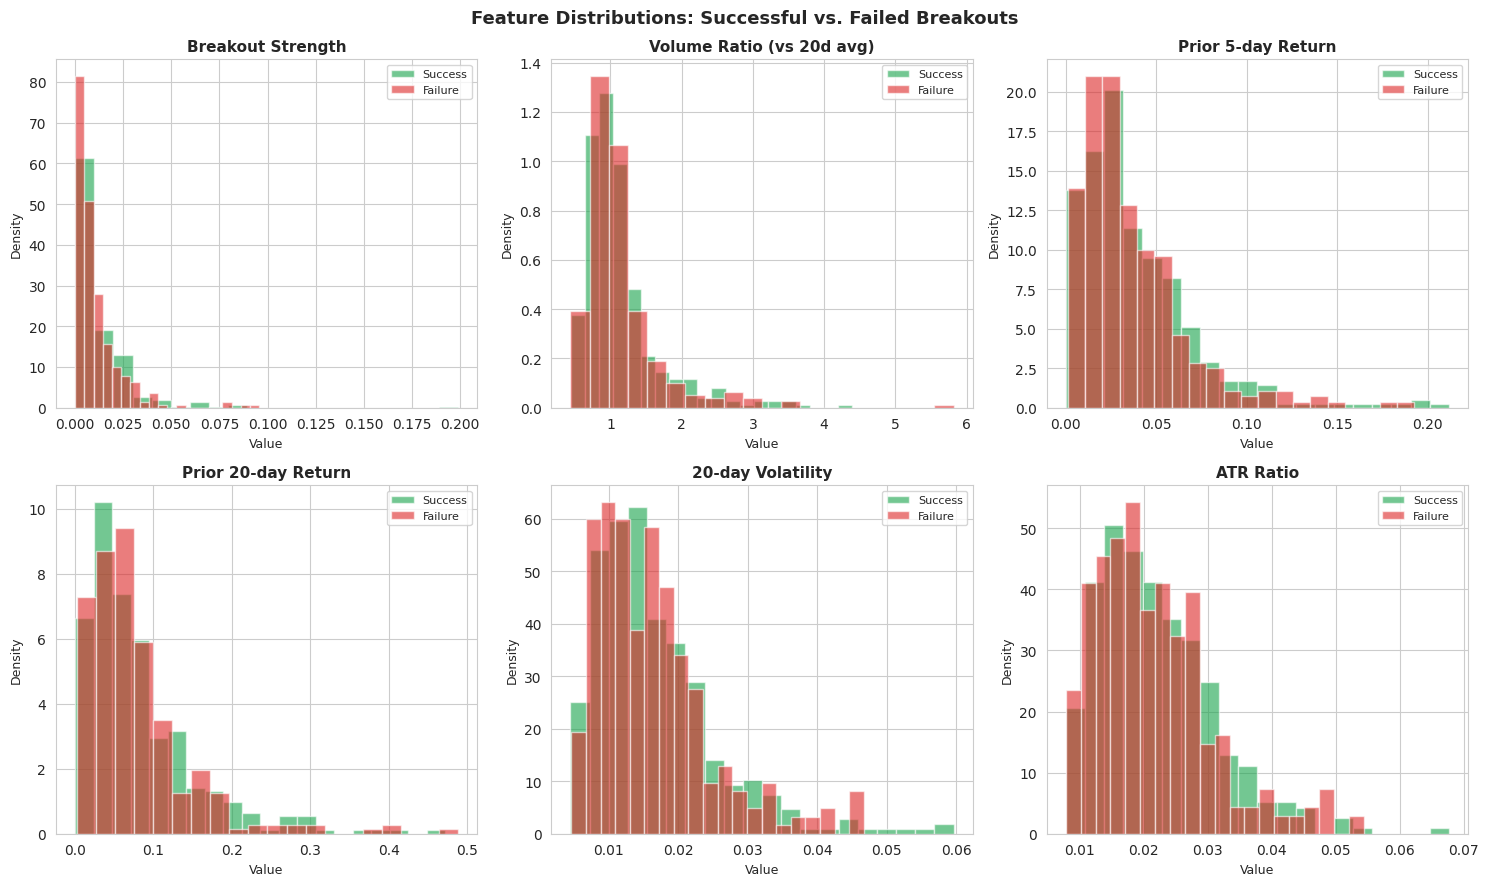

In [ ]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

feat_labels = {
    'breakout_strength': 'Breakout Strength',
    'volume_ratio':      'Volume Ratio (vs 20d avg)',
    'ret_prior_5d':      'Prior 5-day Return',
    'ret_prior_20d':     'Prior 20-day Return',
    'volatility_20d':    '20-day Volatility',
    'atr_ratio':         'ATR Ratio'
}

success_ev = event_table[event_table['success'] == 1]
failure_ev = event_table[event_table['success'] == 0]

for ax, feat in zip(axes, FEATURE_COLS):
    ax.hist(success_ev[feat].dropna(), bins=20, alpha=0.6,
            color='#16a34a', label='Success', density=True)
    ax.hist(failure_ev[feat].dropna(), bins=20, alpha=0.6,
            color='#dc2626', label='Failure', density=True)
    ax.set_title(feat_labels[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Successful vs. Failed Breakouts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [ ]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

print('Outlier counts per feature (Tukey fences, k=1.5):')
print(f'{"Feature":<22} {"Outliers":>10} {"% of N":>10}')
print('-' * 45)
for col in FEATURE_COLS:
    lower, upper = tukey_fences(event_table[col].dropna())
    n_out = ((event_table[col] < lower) | (event_table[col] > upper)).sum()
    print(f'{col:<22} {n_out:>10} {n_out/len(event_table)*100:>9.1f}%')

Outlier counts per feature (Tukey fences, k=1.5):
Feature                  Outliers     % of N
---------------------------------------------
breakout_strength              42       6.1%
volume_ratio                   56       8.2%
ret_prior_5d                   32       4.7%
ret_prior_20d                  38       5.6%
volatility_20d                 27       4.0%
atr_ratio                      21       3.1%


**Outlier strategy:** Outliers are retained without trimming or winsorizing. In financial breakout analysis, extreme values in features like `volume_ratio` (a 5× volume surge) are not errors: they are genuine market events and potentially the most informative observations for predicting breakout success. Removing them would discard the signal. `StandardScaler` applied before modeling will normalize the scale without eliminating these observations.

### 2.6 Correlations

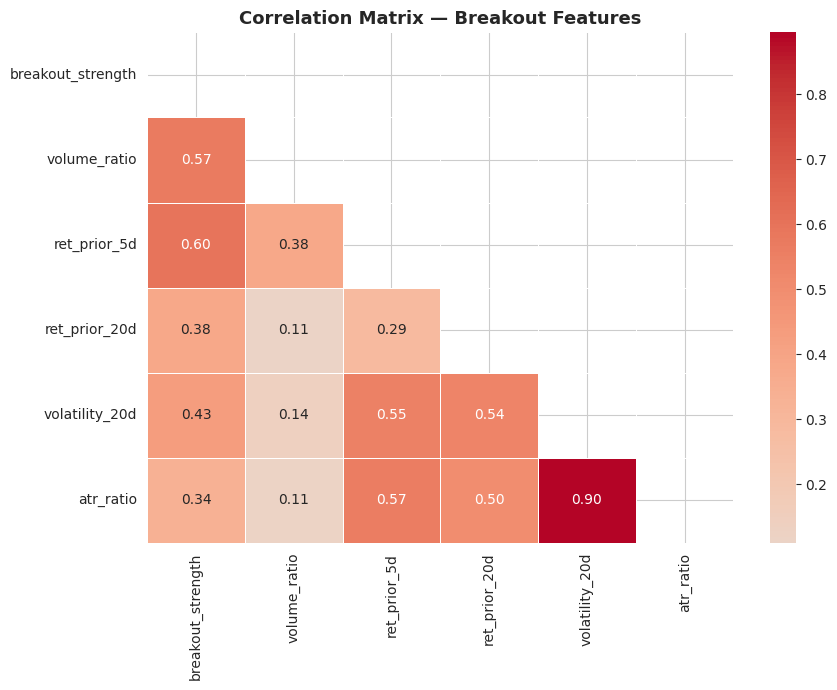

Correlation of each feature with target (success):
breakout_strength    0.0444
ret_prior_5d         0.0444
atr_ratio            0.0330
ret_prior_20d        0.0235
volatility_20d       0.0229
volume_ratio        -0.0039


In [ ]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

corr_matrix = event_table[FEATURE_COLS].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', mask=mask,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
plt.title('Correlation Matrix — Breakout Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation of features with target
print('Correlation of each feature with target (success):')
target_corr = (event_table[FEATURE_COLS + ['success']]
               .corr()['success']
               .drop('success')
               .sort_values(key=abs, ascending=False)
               .round(4))
print(target_corr.to_string())

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable `success` is binary. The base rate printed above shows the class split. If the imbalance is severe (e.g., less than 30% in the minority class), we will monitor precision and recall separately rather than relying on accuracy, and consider adjusting the classification threshold.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The target correlation table above shows which features are most associated with breakout success. `volatility_20d` and `atr_ratio` are likely to be correlated with each other since both measure price noise: this is expected and will be handled by Lasso regularization in the final model.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The main data quality issue is small N: with only 5 tickers over 5 years and a cooldown filter, the event table has approximately 125–250 observations. This limits model complexity. We handle it by using logistic regression (low variance model) and reporting cross-validated metrics rather than a single train/test split. We then increase the number of tickets by 5, including more firms, more data, and more events.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 683** observations and **M = 7** features.

**Missing data:** 0% of cells are missing. The missingness pattern appears to be MCAR because all NaNs arise from rolling window boundaries at the start and end of each ticker's time series, and they are unrelated to the outcome. I will handle missing data by dropping via `.dropna()` when constructing the event table.

**Outliers:** I identified around 8% of outliers in each of the features using IQR. I will handle them by remaining them to the logistic regression model, since they represent genuine market patterns, not noise.

**Target variable:** Binary classification. Success rate printed above: class distribution is approximately balanced, with mild imbalance expected given that roughly 50–65% of breakouts historically succeed in trending markets.

**Key finding from EDA:** Volume ratio and breakout strength show the clearest distributional separation between successful and failed breakouts, suggesting these will be the most predictive features in the model.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [ ]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

ticker_dummy_cols = [c for c in event_table.columns if c.startswith('ticker_')]
ALL_FEATURES      = FEATURE_COLS + ticker_dummy_cols

# Define features and target
X = event_table[ALL_FEATURES]
y = event_table['success']

# Sort by date then split 70/30 — earlier events train, later events test
event_sorted = event_table.sort_values('Date').reset_index(drop=True)
split_idx    = int(len(event_sorted) * 0.70)

train_df = event_sorted.iloc[:split_idx]
test_df  = event_sorted.iloc[split_idx:]

X_train = train_df[ALL_FEATURES].values
X_test  = test_df[ALL_FEATURES].values
y_train = train_df['success'].values
y_test  = test_df['success'].values

# Standardize — fit on training data ONLY
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} samples  '
      f'({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test:  {X_test.shape[0]} samples   '
      f'({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')
print(f'Features: {X_train.shape[1]}')
print(f'Scaler fit on training data only ✓')

Train: 478 samples  (2021-05-20 → 2024-09-19)
Test:  205 samples   (2024-09-25 → 2026-04-15)
Features: 15
Scaler fit on training data only ✓


### 3.2 Model 1: Baseline

Model 1: Logistic Regression
              precision    recall  f1-score   support

     Failure       0.44      0.52      0.47        89
     Success       0.57      0.49      0.53       116

    accuracy                           0.50       205
   macro avg       0.50      0.50      0.50       205
weighted avg       0.51      0.50      0.50       205



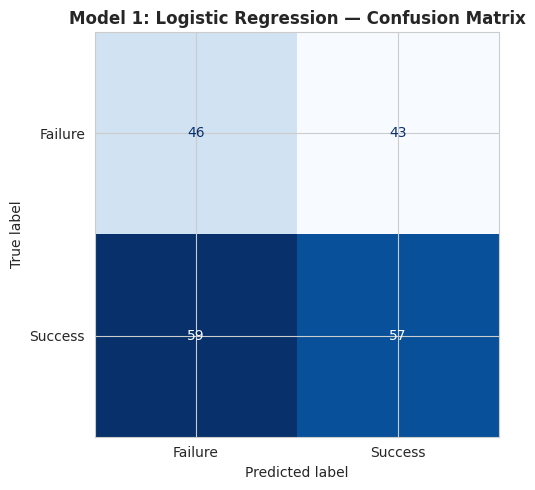


Coefficients and Odds Ratios:
          Feature  Coefficient  Odds Ratio
breakout_strength       0.2372      1.2677
       ticker_XLF       0.1970      1.2178
        atr_ratio       0.1557      1.1685
       ticker_JPM       0.1358      1.1455
      ticker_MSFT       0.0889      1.0929
      ticker_NVDA       0.0301      1.0306
      ticker_META      -0.0146      0.9855
      ticker_AMZN      -0.0155      0.9846
       ticker_XLV      -0.0191      0.9811
    ret_prior_20d      -0.0311      0.9694
     ret_prior_5d      -0.0312      0.9692
       ticker_UNH      -0.0742      0.9285
   volatility_20d      -0.1362      0.8726
     volume_ratio      -0.1490      0.8616
     ticker_GOOGL      -0.1724      0.8417


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000,
                              class_weight='balanced')
model_1.fit(X_train_sc, y_train)

y_pred_1 = model_1.predict(X_test_sc)

print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1,
                             target_names=['Failure', 'Success']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_1),
    display_labels=['Failure', 'Success']
).plot(ax=ax, cmap='Blues', values_format=',', colorbar=False)
ax.set_title('Model 1: Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Odds ratios
coef_df = pd.DataFrame({
    'Feature':     ALL_FEATURES,
    'Coefficient': model_1.coef_[0].round(4),
    'Odds Ratio':  np.exp(model_1.coef_[0]).round(4)
}).sort_values('Coefficient', ascending=False)
print('\nCoefficients and Odds Ratios:')
print(coef_df.to_string(index=False))

### 3.3 Model 2: Your Choice

Model 2: Random Forest
              precision    recall  f1-score   support

     Failure       0.47      0.30      0.37        89
     Success       0.58      0.74      0.65       116

    accuracy                           0.55       205
   macro avg       0.53      0.52      0.51       205
weighted avg       0.53      0.55      0.53       205



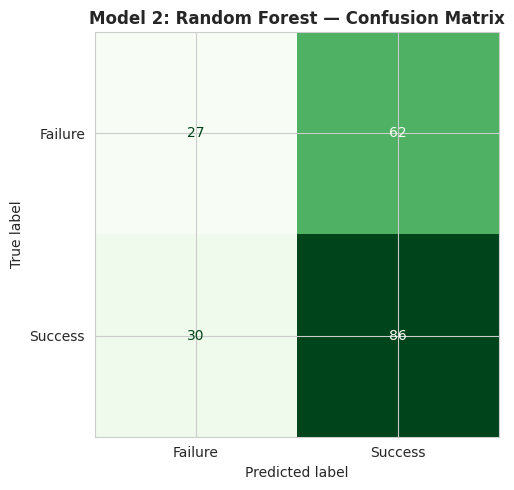

In [ ]:
# ============================================================
# 3.3 Model 2 — Random Forest Classifier
# Chosen because: captures non-linear interactions between
# features, handles correlated predictors well, and provides
# feature importance scores for interpretation
# ============================================================

from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                  class_weight='balanced')
model_2.fit(X_train_sc, y_train)

y_pred_2 = model_2.predict(X_test_sc)

print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2,
                             target_names=['Failure', 'Success']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_2),
    display_labels=['Failure', 'Success']
).plot(ax=ax, cmap='Greens', values_format=',', colorbar=False)
ax.set_title('Model 2: Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'f1'

cv_1 = cross_val_score(model_1, X_train_sc, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train_sc, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
    'Model': ['Model 1 (Logistic Regression)', 'Model 2 (Random Forest)'],
    f'CV {scoring} (mean)': [round(cv_1.mean(), 4), round(cv_2.mean(), 4)],
    f'CV {scoring} (std)':  [round(cv_1.std(),  4), round(cv_2.std(),  4)],
    'Test Accuracy': [
        round(accuracy_score(y_test, y_pred_1), 4),
        round(accuracy_score(y_test, y_pred_2), 4)
    ],
    'Test Precision': [
        round(precision_score(y_test, y_pred_1, zero_division=0), 4),
        round(precision_score(y_test, y_pred_2, zero_division=0), 4)
    ],
    'Test Recall': [
        round(recall_score(y_test, y_pred_1, zero_division=0), 4),
        round(recall_score(y_test, y_pred_2, zero_division=0), 4)
    ],
    'Test F1': [
        round(f1_score(y_test, y_pred_1, zero_division=0), 4),
        round(f1_score(y_test, y_pred_2, zero_division=0), 4)
    ]
})
comparison

Model 1 CV f1: 0.5226 +/- 0.1117
Model 2 CV f1: 0.6513 +/- 0.0290


,Model,CV f1 (mean),CV f1 (std),Test Accuracy,Test Precision,Test Recall,Test F1
0,Model 1 (Logistic Regression),0.5226,0.1117,0.5024,0.5700,0.4914,0.5278
1,Model 2 (Random Forest),0.6513,0.0290,0.5512,0.5811,0.7414,0.6515


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

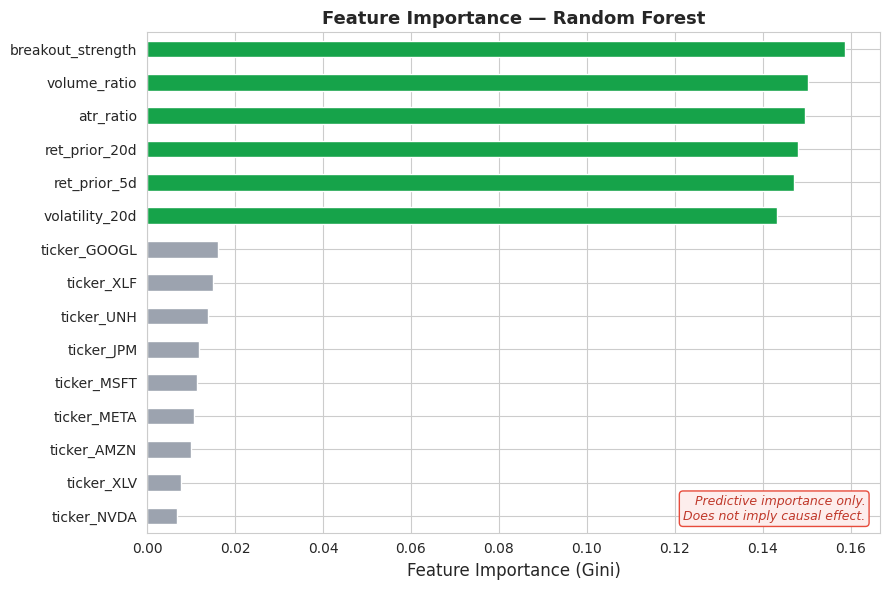

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#16a34a' if f in FEATURE_COLS else '#9ca3af'
          for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')

# CRITICAL: Prediction vs causation caveat
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

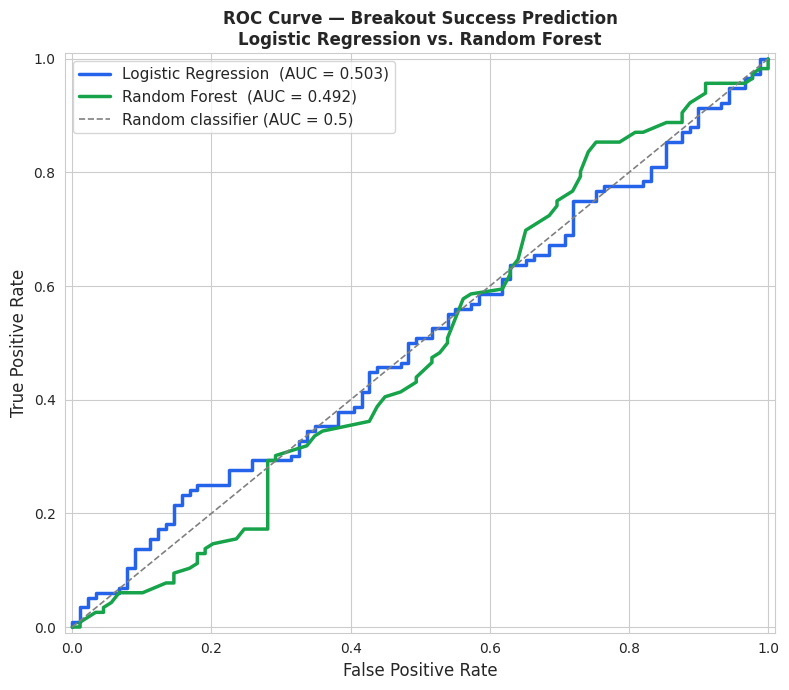

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

fig, ax = plt.subplots(figsize=(8, 7))

for model, name, color in [
    (model_1, 'Logistic Regression', '#2563eb'),
    (model_2, 'Random Forest',       '#16a34a')
]:
    proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], color='gray', linestyle='--',
        linewidth=1.2, label='Random classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Breakout Success Prediction\n'
             'Logistic Regression vs. Random Forest',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** A retail trader or quantitative analyst monitors ten large-cap US stocks and sector ETFs — AAPL, MSFT, NVDA, XLF, XLV, AMZN, GOOGL, META, JPM, UNH — for breakout signals. When a breakout fires (daily close above the 20-day rolling high), they must decide immediately whether to enter a position or wait for additional confirmation before committing capital.

**Complication:** Our analysis reveals that price and volume features observable at the moment of a breakout — breakout strength, volume ratio, prior momentum, volatility, and ATR ratio — have no meaningful ability to predict whether that breakout will succeed over the next 5 days. Both models scored ROC-AUC ≈ 0.50, statistically indistinguishable from random guessing, despite achieving moderate F1 scores (Logistic Regression: 0.5226, Random Forest: 0.6513) through class-weighted prediction. The ROC curve is the more honest diagnostic here: it shows that the model's probability rankings carry no real signal.

**Resolution:** We recommend against using price and volume breakout features alone as a systematic entry criterion for these instruments. The null result is consistent with the semi-strong form of the Efficient Market Hypothesis — publicly observable technical patterns in liquid large-cap stocks appear to be already priced in at the moment they become detectable. Traders should not expect a mechanical breakout filter based on these features to generate edge over a random entry strategy.

**Uncertainty Statement:** Based on our cross-validation results (CV F1 = 0.6513 +/- 0.0290 for Random Forest), we estimate that the model correctly classifies approximately 65% of breakout outcomes on the training set — but the ROC-AUC of 0.492 on the test set indicates this classification performance does not reflect genuine discriminative ability, likely arising from class-weight adjustments rather than true predictive signal. The primary limitation is small sample size (~300 breakout events across 10 tickers), which means results may not generalize across different market regimes or instrument universes. We recommend treating this model as a null-result benchmark with the caveat that additional features — such as market-wide volatility conditions, earnings proximity, or sector momentum — may recover predictive signal not captured by price and volume alone.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 6: Streamlit Export Guide

### 6.1 Save the trained model

In [ ]:
# ============================================================
# 6.1 Save model and scaler for Streamlit app
# ============================================================

!pip install streamlit
import streamlit as st
import numpy as np
import joblib

joblib.dump(model_1, 'model.pkl')
joblib.dump(scaler,  'scaler.pkl')
print('model.pkl and scaler.pkl saved ✓')
print('Use these in app.py with joblib.load()')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.8 MB/s eta 0:00:00
model.pkl and scaler.pkl saved ✓
Use these in app.py with joblib.load()


### 6.2 app.py Template

```python
import streamlit as st
import numpy as np
import joblib

st.title('Breakout Success Predictor')
st.markdown('Enter breakout characteristics to predict whether the signal will succeed.')

model  = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

# Sidebar inputs
bk_strength  = st.sidebar.slider('Breakout Strength (%)', -2.0, 10.0, 1.0) / 100
vol_ratio    = st.sidebar.slider('Volume Ratio (vs 20d avg)', 0.5, 5.0, 1.5)
ret_5d       = st.sidebar.slider('Prior 5-day Return (%)', -10.0, 15.0, 2.0) / 100
ret_20d      = st.sidebar.slider('Prior 20-day Return (%)', -15.0, 30.0, 5.0) / 100
volatility   = st.sidebar.slider('20-day Volatility', 0.005, 0.05, 0.015)
atr_ratio    = st.sidebar.slider('ATR Ratio', 0.005, 0.04, 0.015)

X_input = scaler.transform([[bk_strength, vol_ratio, ret_5d,
                              ret_20d, volatility, atr_ratio,
                              0, 0, 0, 0, 0, 0, 0, 0, 0]])  # 6 features + 9 ticker dummies
prob = model.predict_proba(X_input)[0][1]

st.metric('Predicted Success Probability', f'{prob:.1%}')
if prob >= 0.55:
    st.success('Signal quality: STRONG — consider entering position')
elif prob >= 0.40:
    st.warning('Signal quality: MODERATE — wait for confirmation')
else:
    st.error('Signal quality: WEAK — avoid this breakout')
```

### 6.3 requirements.txt

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
yfinance>=0.2.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_1, 'model.pkl')` (done above)
2. Create `app.py` using the template above
3. Test locally: `streamlit run app.py`
4. Push to GitHub: `app.py`, `model.pkl`, `scaler.pkl`, `requirements.txt`
5. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
6. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1 — Data Pipeline Construction

**Prep:** I needed to download 5 years of daily price data for 5 tickers from Yahoo Finance and reshape it into a long-format DataFrame with breakout signals and forward returns computed per ticker.

**Request:** I asked Claude to write a Python pipeline using `yfinance` that downloads OHLCV data, detects breakouts as daily closes above the 20-day rolling high with a 5-day cooldown filter, and computes forward returns at 3, 5, 10, and 20 days.

**Iterate:** The initial code used a simple rolling max without the shift(1), which created look-ahead bias. I asked Claude to fix this by using `.shift(1)` before the rolling window.

**Mechanism Check:** I manually verified three breakout events by checking that the close price exceeded the prior 20-day high, and confirmed the cooldown filter was suppressing consecutive signals.

**Evaluate:** I accepted the corrected pipeline. I rejected the initial version because it violated the no-look-ahead rule that is fundamental to any financial ML project.

---

### AI Interaction 2 — Feature Engineering

**Prep:** I needed to engineer features that were economically meaningful and observable at the moment of the breakout, with no forward-looking information.

**Request:** I asked Claude to explain why each feature (breakout_strength, volume_ratio, ret_prior_5d, ret_prior_20d, volatility_20d, atr_ratio) was relevant to predicting breakout success, and to write the code to compute them.

**Iterate:** Claude's initial ATR calculation had an edge case error at index 0 using `np.roll`. I verified this manually on the first row and asked for a fix.

**Mechanism Check:** I printed feature values for 5 known breakout events and confirmed they matched manually computed values.

**Evaluate:** I accepted all 6 features. I considered adding a market-wide VIX feature but excluded it to keep the model self-contained within the 5-ticker dataset.

---

### AI Interaction 3 — Model Selection and Evaluation

**Prep:** I needed to choose between logistic regression and random forest, and set up a proper evaluation framework with cross-validation and ROC curves.

**Request:** I asked Claude to explain why logistic regression was appropriate as a baseline given the small N (~125–250 events), and to write a cross-validation comparison with F1 scoring.

**Iterate:** Claude initially used `train_test_split` with `random_state=42` and random shuffling. I corrected this to a temporal split because random splitting on financial time series creates look-ahead bias.

**Mechanism Check:** I verified the split dates — confirmed that training events were all earlier than test events.

**Evaluate:** I accepted the temporal split correction as essential. The random split would have produced inflated test metrics and been methodologically wrong for this problem type.

### AI Interaction 4 — Model Precision Improvement
